In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import leaves_list
from cobra.io import read_sbml_model


# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from PAModelpy.utils import set_up_pam
from Scripts.pam_generation import setup_ecoli_pam as set_up_ecoli_pam_curated

from Modules.utils.pamparametrizer_analysis import (get_results_from_simulations,
                                                   calculate_error_for_reactions, calculate_r_squared_for_reaction,
                                                   calculate_difference_simulation_experiment)
from Modules.utils.pam_generation import (create_pamodel_from_diagnostics_file,
                                          _extract_reaction_id_from_catalytic_reaction_id)
from Scripts.i3_analysis.metabolic_flux_distribution_vs_exp import RXNS_TO_VALIDATE, get_reactions2plot_pathway_mapping



# from Modules.utils import calculate_r_squared_for_reaction
# from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations
N_ALT_MODELS = 10

ECOLI_PHENOTYPE_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes')

MODEL_FILE_PATH = os.path.join('Models', 'iML1515.xml')

PARAM_FILE_OLD = os.path.join('Results', '1_preprocessing','proteinAllocationModel_iML1515_EnzymaticData_250912.xlsx')
PARAM_FILE_SCALED = os.path.join('Results', '2_parametrization','proteinAllocationModel_iML1515_EnzymaticData_multi.xlsx')

BEST_INDIV_RESULT_FILES = [os.path.join('Results','2_parametrization','diagnostics',
                                     f'pam_parametrizer_diagnostics_{i}.xlsx') for i in range(1,N_ALT_MODELS+1)]

Loading PAModelpy modules version 0.5.2
Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-03


# 1. Load reference data

In [2]:
# load flux data glucose
flux_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py_rev.xls'),
                       sheet_name = 'Fluxes',
                            index_col=1)
flux_df.head()

,Description,Reaction_position,Rijsewijk_2011,Nanchen_2006_1,Nanchen_2006_2,Nanchen_2006_3,Nanchen_2006_4
Reaction_ID,,,,,,,
EX_glc__D_e,Glucose uptake,2805,8.26,1.670000,2.800000,4.220000,5.650000
BIOMASS_Ec_iML1515_WT_75p37M,Growth rate,2712,0.61,0.085000,0.187000,0.286000,0.399000
EX_ac_e,Acetate secretion,34,4.89,0.000000,0.000000,0.000000,0.000000
PGI,Upper EMP (pgi),102,5.81,1.204014,1.565375,2.653420,3.625868
G6PDH2r,Upper PPP (zwf),658,2.29,0.461701,1.263167,1.639352,2.058864


# 2. Setup the *Escherichia coli* iML1515 model with new parameters

In [3]:
#setup the model
ecoli_pam_wt = set_up_pam(PARAM_FILE_OLD, 
                          model = MODEL_FILE_PATH, 
                          sensitivity=False) # not curation for reference
ecoli_pam_curated = set_up_ecoli_pam_curated(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),
    sensitivity = False) # curated for reference

pam = set_up_pam(PARAM_FILE_SCALED, 
                 model = MODEL_FILE_PATH,
                 sensitivity = False)
pam.change_reaction_bounds('EX_glc__D_e', lower_bound=0)

new_ecoli_pams = {alt+1: create_pamodel_from_diagnostics_file(file,
                                          pam.copy(copy_with_pickle=True)) for alt, file in enumerate(BEST_INDIV_RESULT_FILES)}

No enzyme information found for reaction: ICHORS_copy2
No enzyme information found for reaction: ICHORS_copy1
No enzyme information found for reaction: SUCFUMtpp
No enzyme information found for reaction: THMDt2pp_copy1
No enzyme information found for reaction: THMDt2pp_copy2
No enzyme information found for reaction: URIt2pp_copy1
No enzyme information found for reaction: URIt2pp_copy2
No enzyme information found for reaction: ADNt2pp_copy1
No enzyme information found for reaction: ADNt2pp_copy2
No enzyme information found for reaction: GUAtpp
No enzyme information found for reaction: HYXNtpp
No enzyme information found for reaction: FUCtpp
No enzyme information found for reaction: CYTDt2pp_copy1
No enzyme information found for reaction: CYTDt2pp_copy2
No enzyme information found for reaction: CADVtpp
No enzyme information found for reaction: FEENTERtpp
No enzyme information found for reaction: FORtppi
No enzyme information found for reaction: RMNtpp
No enzyme information found for reac

/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:252: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

No enzyme information found for reaction: ICHORS_copy2
No enzyme information found for reaction: ICHORS_copy1
No enzyme information found for reaction: SUCFUMtpp
No enzyme information found for reaction: THMDt2pp_copy1
No enzyme information found for reaction: THMDt2pp_copy2
No enzyme information found for reaction: URIt2pp_copy1
No enzyme information found for reaction: URIt2pp_copy2
No enzyme information found for reaction: ADNt2pp_copy1
No enzyme information found for reaction: ADNt2pp_copy2
No enzyme information found for reaction: GUAtpp
No enzyme information found for reaction: HYXNtpp
No enzyme information found for reaction: FUCtpp
No enzyme information found for reaction: CYTDt2pp_copy1
No enzyme information found for reaction: CYTDt2pp_copy2
No enzyme information found for reaction: CADVtpp
No enzyme i

# 3. Check internal flux distribution (glucose as C source)

## 3.1 Run the simulations and calculate the errors

In [4]:
# Get the data from the MFA studies of Rijsewijk et al (2011) and Nanchen et al. (2006)
new_indices = []
for i, row in flux_df.iterrows():
    if isinstance(row.name, str):
        if row.name[-2:] == '_b':
            new_indices.append(row.name[:-2])
            fluxes_to_simulate.loc[row.name]= -row
        if row.name[-2:] == '_f':
            new_indices.append(row.name[:-2])
        else: 
            new_indices.append(row.name)
    else:
        new_indices.append(row.name)
            
flux_df.index = new_indices
flux_df_data = flux_df.drop(['Description', 'Reaction_position'], axis =1)


fluxes_to_save = None
flux_information = {}
validation_df = pd.DataFrame(columns = new_indices)
studies = []
substrate_uptake = []
for study, fluxes in flux_df_data.items():
    studies += [study]
    substrate_uptake += [-fluxes.loc['EX_glc__D_e']]
    flux_information[study] = fluxes.to_dict()
    validation_df = pd.concat([validation_df,fluxes.to_frame().T], ignore_index =True)
    
    #store the names of the fluxes to save
    if fluxes_to_save is None:
        fluxes_to_save = list(fluxes.index)
print(fluxes_to_save)


['EX_glc__D_e', 'BIOMASS_Ec_iML1515_WT_75p37M', 'EX_ac_e', 'PGI', 'G6PDH2r', 'EDA', 'CS', 'ICL', 'PPC', 'ME1', 'ME2']


In [5]:
validation_df

,EX_glc__D_e,BIOMASS_Ec_iML1515_WT_75p37M,EX_ac_e,PGI,G6PDH2r,EDA,CS,ICL,PPC,ME1,ME2
0,8.26,0.610,4.89,5.810000,2.290000,0.765000,2.245000,0.000000,2.780000,0.530000,0.530000
1,1.67,0.085,0.00,1.204014,0.461701,0.113477,2.036011,0.963408,0.511215,0.003525,0.003525
2,2.80,0.187,0.00,1.565375,1.263167,0.294722,2.879840,1.322975,0.834799,0.410990,0.410990
3,4.22,0.286,0.00,2.653420,1.639352,0.378028,4.348612,0.541035,1.674173,0.670016,0.670016
4,5.65,0.399,0.00,3.625868,2.058864,0.409410,5.481990,0.000000,2.586144,0.458187,0.458187


In [6]:
kwargs = {'substrate_ids': ['EX_glc__D_e'], 
          'substrate_rates': [substrate_uptake],
          'fluxes_to_save' : fluxes_to_save}
# for each study, run simulations
fluxes_gem = get_results_from_simulations(read_sbml_model(MODEL_FILE_PATH), **kwargs)['fluxes']
fluxes_curated = get_results_from_simulations(ecoli_pam_curated, **kwargs)['fluxes']
print('\n')
fluxes_wt = get_results_from_simulations(ecoli_pam_wt,**kwargs)['fluxes']
print('\n')
# fluxes_new = run_simulations(ecoli_pam_new, **kwargs)

for alt, pam in new_ecoli_pams.items():
    pam.change_reaction_bounds('EX_glc__D_e', 0, 1e3)
    new_ecoli_pams[alt] = pam

fluxes_new_dict = {alt: get_results_from_simulations(pam, **kwargs)['fluxes'] for alt, pam in new_ecoli_pams.items()}

Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e)

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


...

Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


In [7]:
#calculate R^2 value between simulations and experiments
error_gem = calculate_error_for_reactions(validation_df,
                                                 fluxes_gem,
                                                 fluxes_to_save[1:])
print('R^2 values for the genome scale model :', np.nanmean(error_gem))
error_curated = calculate_error_for_reactions(validation_df,
                                                 fluxes_curated,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with published parameter set :', np.nanmean(error_curated))

error_wt = calculate_error_for_reactions(validation_df,
                                                 fluxes_wt,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with parameters from GotEnzymes: ', np.nanmean(error_wt))


error_new_dict = {alt: calculate_error_for_reactions(validation_df,
                                                  fluxes,
                                                  fluxes_to_save[1:]) for alt, fluxes in fluxes_new_dict.items()}
for alt, error_list in error_new_dict.items():
    print(f'R^2 values for alternative model {alt} with the optimized parameters: ', np.nanmean(error_list))




R^2 values for the genome scale model : -1.235291581235627
R^2 values for the model with published parameter set : -1.1960816253884783
R^2 values for the model with parameters from GotEnzymes:  -3.615766693374821
R^2 values for alternative model 1 with the optimized parameters:  -59.347964415883496
R^2 values for alternative model 2 with the optimized parameters:  -1.2601852652975356
R^2 values for alternative model 3 with the optimized parameters:  -2.91749298381714
R^2 values for alternative model 4 with the optimized parameters:  -2.125244460465247
R^2 values for alternative model 5 with the optimized parameters:  -2.0702823355114526
R^2 values for alternative model 6 with the optimized parameters:  -1.9678351267940009
R^2 values for alternative model 7 with the optimized parameters:  -2.952659355704669
R^2 values for alternative model 8 with the optimized parameters:  -2.807202972522192
R^2 values for alternative model 9 with the optimized parameters:  -2.524292594474126
R^2 values

## 3.2 Visualize the simulation results for the different models

In [8]:
# validation_df_1.index = validation_df.index.str.split(', ')
validation_df_1 = validation_df.T.reset_index()
validation_df_1['index'] = validation_df_1['index'].str.split(', ')
validation_df_1 = validation_df_1.explode('index').set_index('index').T
validation_df_1
# validation_df = validation_df.explode()

index,EX_glc__D_e,BIOMASS_Ec_iML1515_WT_75p37M,EX_ac_e,PGI,G6PDH2r,EDA,CS,ICL,PPC,ME1,ME2
0,8.26,0.610,4.89,5.810000,2.290000,0.765000,2.245000,0.000000,2.780000,0.530000,0.530000
1,1.67,0.085,0.00,1.204014,0.461701,0.113477,2.036011,0.963408,0.511215,0.003525,0.003525
2,2.80,0.187,0.00,1.565375,1.263167,0.294722,2.879840,1.322975,0.834799,0.410990,0.410990
3,4.22,0.286,0.00,2.653420,1.639352,0.378028,4.348612,0.541035,1.674173,0.670016,0.670016
4,5.65,0.399,0.00,3.625868,2.058864,0.409410,5.481990,0.000000,2.586144,0.458187,0.458187


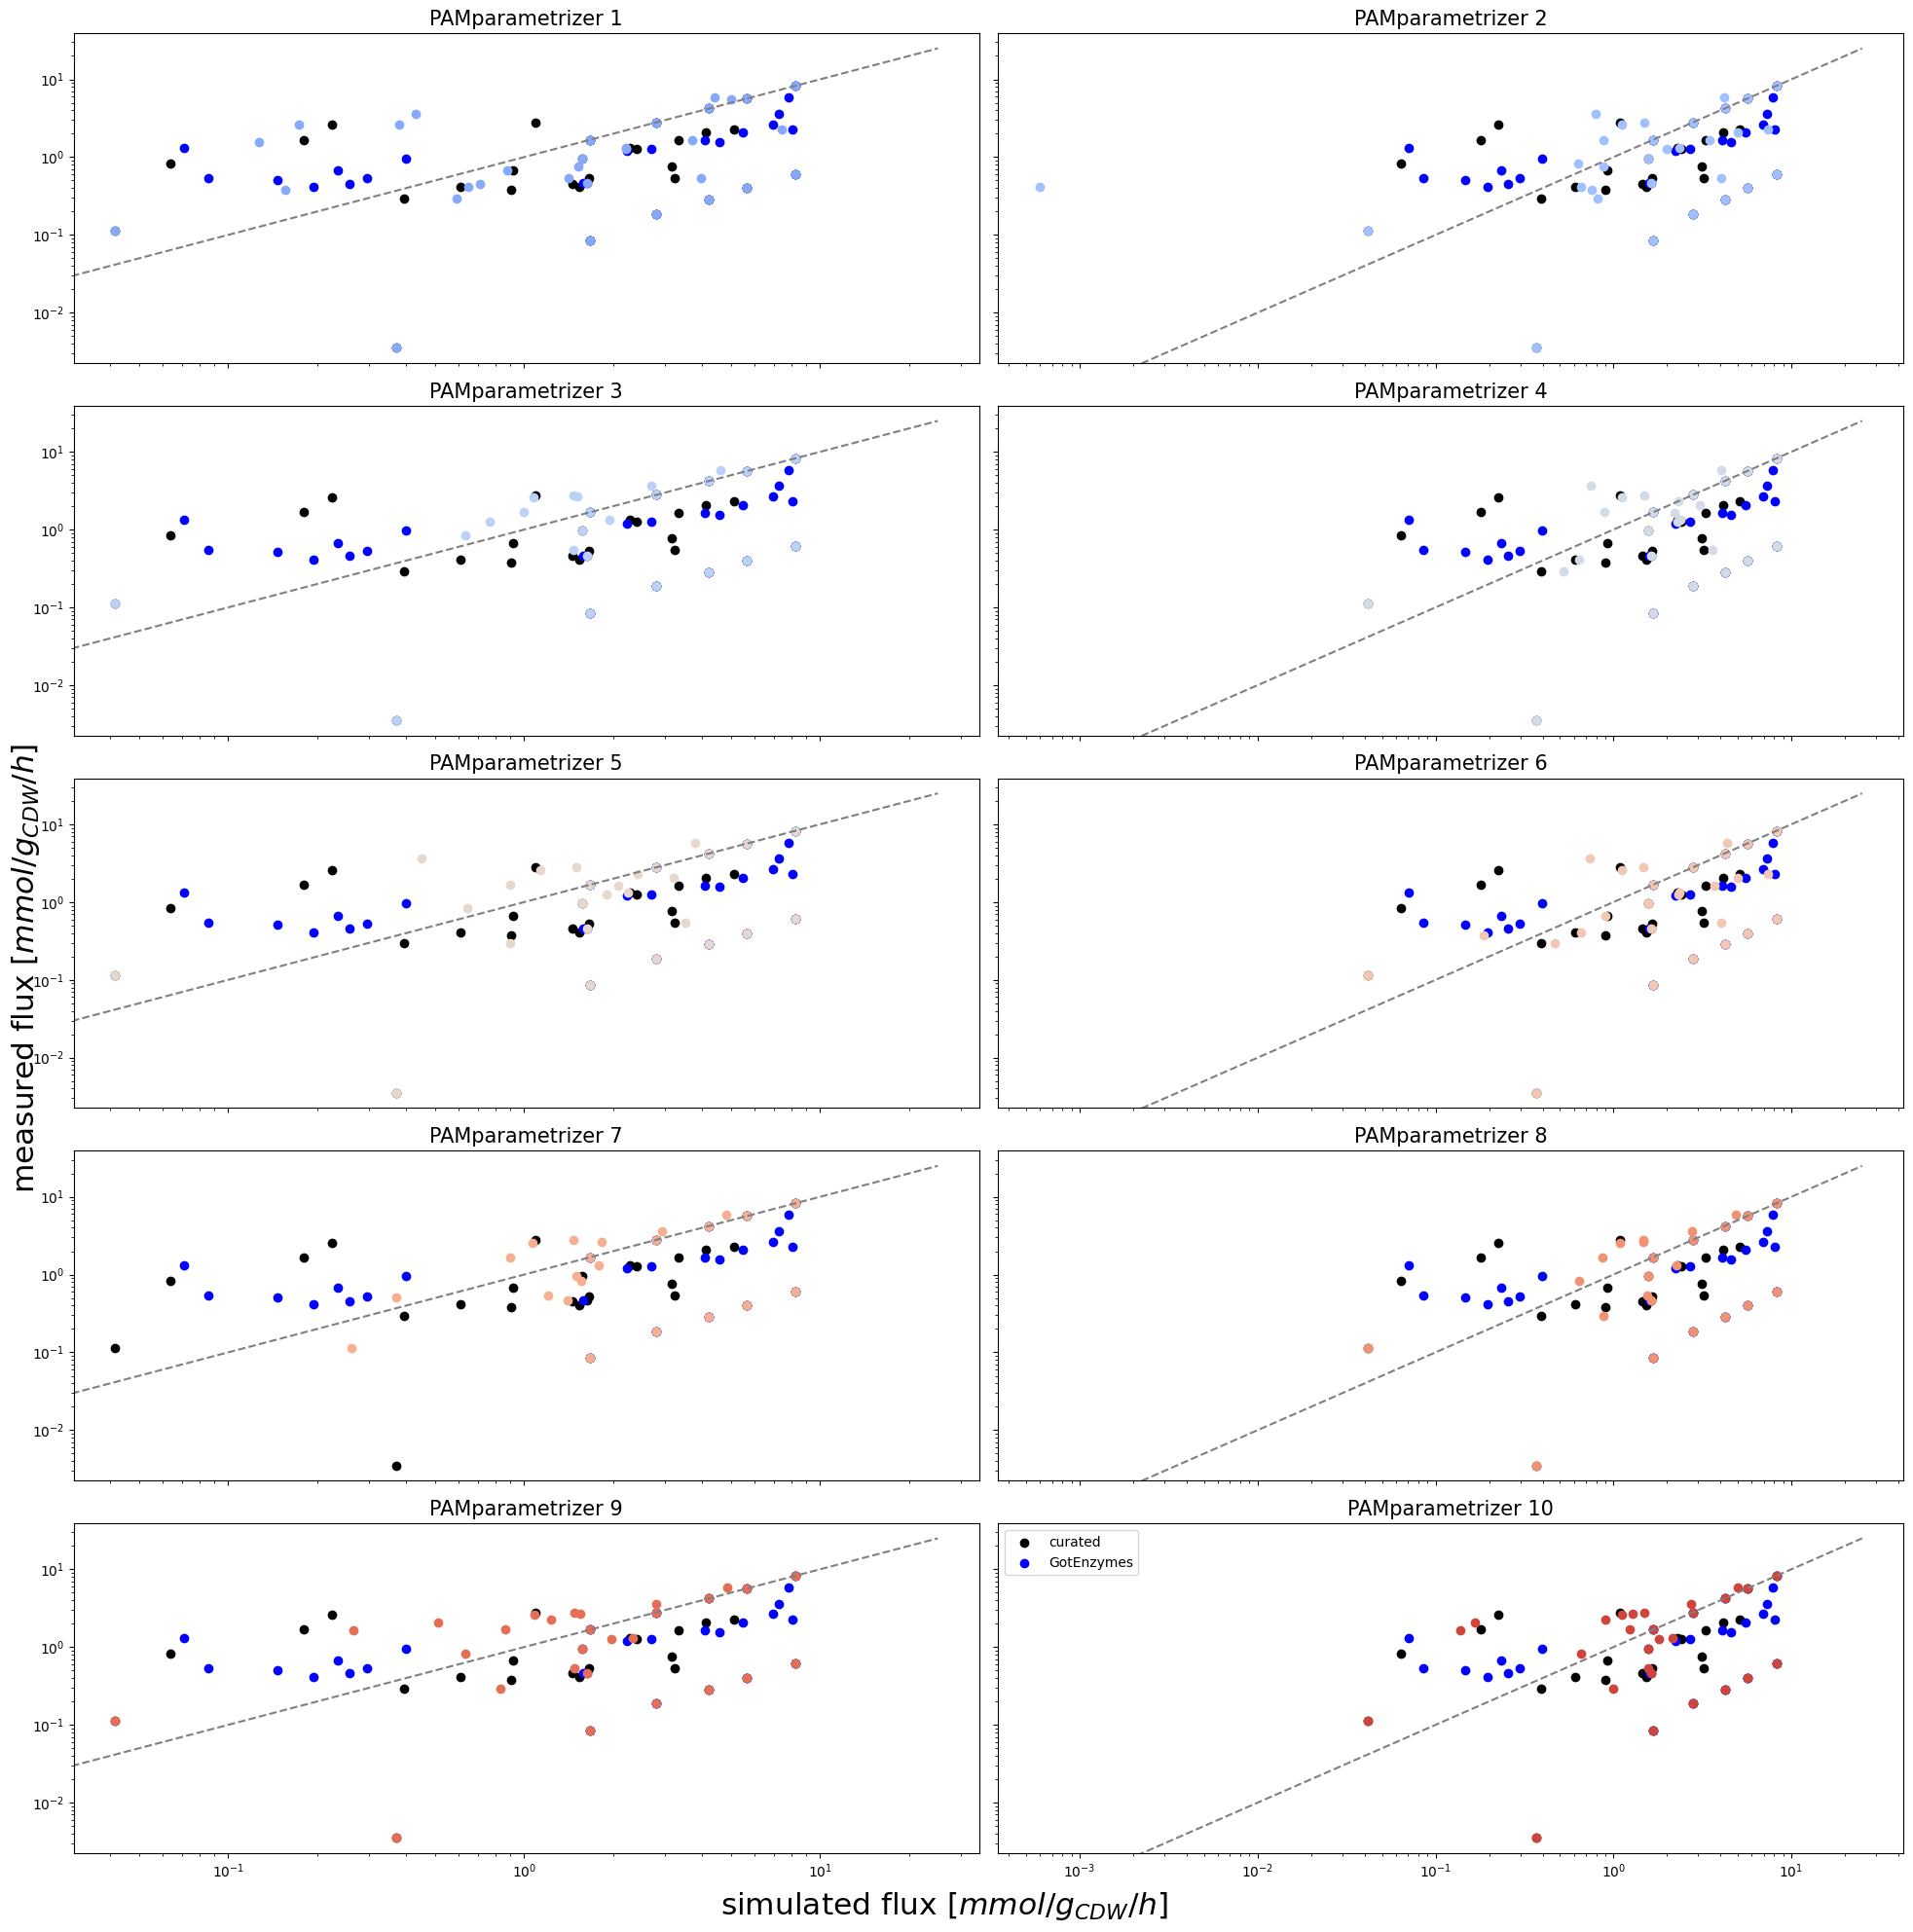

In [9]:
models = ['GotEnzymes','Curated'] + [f'PAMparametrizer {alt}' for alt in range(1,N_ALT_MODELS+1)]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))
fontsize=15

fig, axs = plt.subplots(nrows = int(len(fluxes_new_dict)/2), ncols = 2, sharey='row', sharex='col', figsize = (20,20))
axs = axs.flatten()

for alt, fluxes_new in fluxes_new_dict.items():
    ax = axs[alt-1]
    curated = []
    wt = []
    new = []
    validation = []
    for i in range(len(fluxes_curated)):
        curated += [abs(flx) for flx in fluxes_curated.iloc[i].to_list()[1:-1]]
        if i<len(fluxes_wt):
            wt += [abs(flx) for flx in fluxes_wt.iloc[i].to_list()[1:-1]]
        else:
            wt += [0]*len(fluxes_curated.iloc[i].to_list()[1:-1])
        if i<len(fluxes_new):
            new += [abs(flx) for flx in fluxes_new.iloc[i].to_list()[1:-1]]
        else:
            new += [0]*len(fluxes_curated.iloc[i].to_list()[1:-1])
        validation += validation_df_1.iloc[i].abs().to_list()
    
    ax.plot([0,25], [0,25], linestyle = 'dashed', color='grey')
    ax.scatter(curated, validation, label = 'curated', color = 'black')
    ax.scatter(wt, validation, label = 'GotEnzymes', color ='blue')
    ax.scatter(new, validation, color = cmap[f'PAMparametrizer {alt}'])#, label = f'PAMparametrizer {alt}'
    ax.set_title(f'PAMparametrizer {alt}', fontsize = fontsize)
    ax.set_xscale('log')
    ax.set_yscale('log')

fig.supxlabel('simulated flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
fig.supylabel('measured flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
def plot_significant_annotation(ax, column, sign, compare_df, dodge_factor):
        # Add annotation for significance
        x1, x2 = 1, column
        start = compare_df.Difference.quantile(0.865) +0.65
        y, h = compare_df.Difference.quantile(0.865)+ dodge_factor, 0.75  # Dynamically adjust y position
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, start], lw=1.5, color='k')
        ax.text((x1 + x2) * 0.5, y + h*0.6, sign, ha='center', va='bottom', fontsize=fontsize, color='k')

alternative 1: U-statistic = 1354.5, p-value = 0.23665309968115283
alternative 2: U-statistic = 1370.0, p-value = 0.20496714229055607
alternative 3: U-statistic = 1160.0, p-value = 0.7336921259423931
alternative 4: U-statistic = 1249.0, p-value = 0.5041263208435488
alternative 5: U-statistic = 1243.5, p-value = 0.5192489745832788
alternative 6: U-statistic = 1357.0, p-value = 0.23135952417757033
alternative 7: U-statistic = 1184.5, p-value = 0.6754734873748248
alternative 8: U-statistic = 1181.5, p-value = 0.6828836522747127
alternative 9: U-statistic = 1205.5, p-value = 0.6218297300844247
alternative 10: U-statistic = 1221.5, p-value = 0.5792444495660893


/tmp/ipykernel_155916/1352740041.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)
/tmp/ipykernel_155916/1352740041.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)


NameError: name 'df_list' is not defined

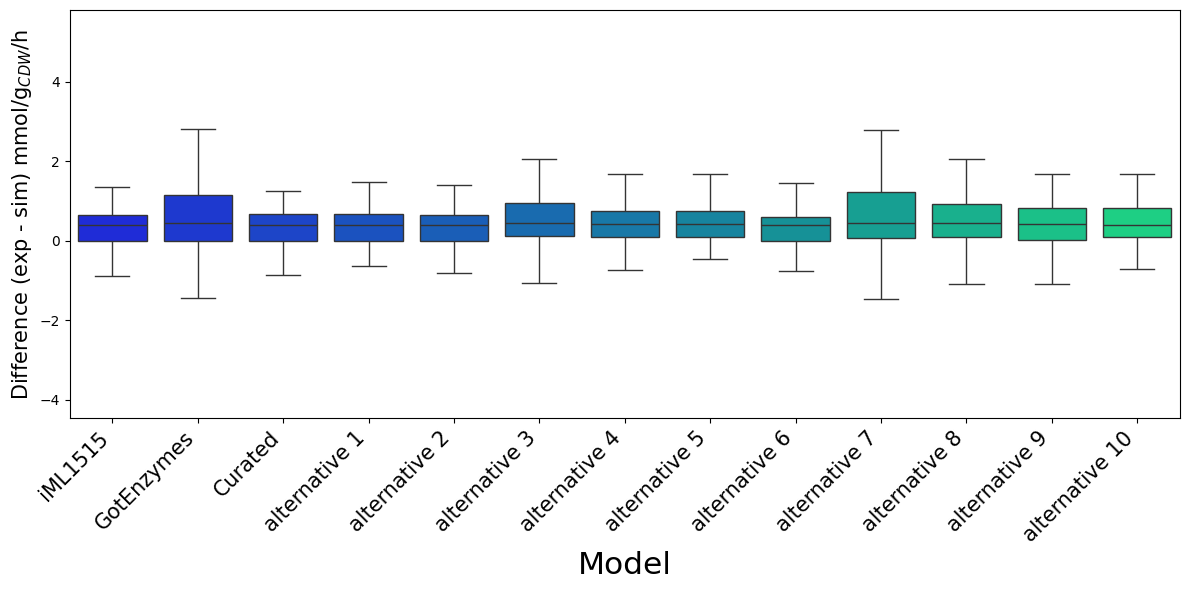

In [11]:
fontsize = 15
models = ['iML1515','GotEnzymes', 'Curated'] + [f'alternative {alt}' for alt in error_new_dict.keys()]
model_colors = sns.color_palette("winter", n_colors=len(models))
cmap = dict(zip(models, model_colors))

# Prepare the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Combine data into a DataFrame
all_differences = pd.DataFrame()
curated_differences = None  # Placeholder for Curated errors
num_significant = 0
df_items = []

for col, (model, sub_df) in enumerate(zip(models, [fluxes_gem, fluxes_wt, fluxes_curated] + list(fluxes_new_dict.values()))):
    differences = []
    for _, row in sub_df.iterrows():
        substrate_id = row['substrate_id']
        difference = calculate_difference_simulation_experiment(
            validation_df_1, row, fluxes_to_save[1:], substrate_id)
        differences += difference

    temp_df = pd.DataFrame({'Model': [model] * len(differences), 'Difference': differences})
    df_items.append({
        'model': model,
        'median': np.median(differences),
        'mean': np.mean(differences),
        'std': np.std(differences),
    })
    # Store curated differences for comparison
    if model == 'GotEnzymes':
        curated_differences = differences
        curated_diff_df = temp_df[temp_df.Model == 'GotEnzymes']
    elif 'PAMparametrizer' in model or 'alternative' in model:
        # Statistical test
        stat, p = mannwhitneyu(curated_differences, differences, alternative='greater')
        print(f"{model}: U-statistic = {stat}, p-value = {p}")
#         if p < 0.075:
#             sign = '*'
#         if p < 0.05:
#             sign = '**'
        if p < 0.01:
            sign = '*'
#         if p < 0.075:
#             num_significant += 1
#             plot_significant_annotation(ax, col, sign, curated_diff_df, 1+num_significant*0.65)

    # Append to the main DataFrame
    all_differences = pd.concat([all_differences, temp_df], ignore_index=True)

# Boxplot or Violin Plot
sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)

# Adjust y-axis to focus on bulk data and add space for annotations
ax.set_ylim([all_differences['Difference'].quantile(0.05)-3, all_differences['Difference'].quantile(0.96)+3])

# Set labels and title
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
ax.set_xlabel('Model', fontsize=fontsize * 1.5)
ax.set_ylabel(r'Difference (exp - sim) mmol/$\text{g}_{CDW}$/h', fontsize=fontsize)

plt.tight_layout()
# plt.show()
plt.savefig('Results/3_analysis/multiple_csources_error_boxplot.png')

df = pd.DataFrame(df_list, columns = ['model', 'median', 'mean', 'stdev'])

df.to_latex()

In [ ]:
# visualize per flux
substrate_ids_cur = fluxes_curated.substrate_id
substrate_ids = fluxes_new_dict[1].substrate_id

# visualize per flux
fluxes_to_plot = fluxes_to_save[3:]
num_fluxes_on_row = int(np.ceil(len(fluxes_to_plot)/2))
fig, axs = plt.subplots(ncols = num_fluxes_on_row, nrows = 2, figsize = [20,8], layout='constrained')
axs = axs.flatten()

# upper_fig_reactions = [rxn for rxn in fluxes_to_save[:5] if rxn != 'EDA'] #EDA is not in core model
# lower_fig_reactions = [rxn for rxn in fluxes_to_save[5:] if rxn != 'EDA']
upper_fig_reactions = [rxn for rxn in fluxes_to_plot[:num_fluxes_on_row]] #EDA is not in core model
lower_fig_reactions = [rxn for rxn in fluxes_to_save[num_fluxes_on_row:]]

fluxes_curated = fluxes_curated.sort_values('substrate')
fluxes_wt = fluxes_wt.sort_values('substrate')
for alt, fluxes in fluxes_new_dict.items():
    fluxes_new_dict[alt] = fluxes.sort_values('substrate')
substrate_rates = [abs(f) for f in fluxes_curated['substrate']]

for i, rxn in enumerate(fluxes_to_plot):
    validation = validation_df[rxn]
    axs[i].scatter(validation_df['EX_glc__D_e'], validation_df[rxn])
    axs[i].plot(substrate_rates, [abs(f) for f in fluxes_gem[rxn]],label = 'iML1515',linestyle='--', color = 'black')
    axs[i].plot(substrate_rates, [abs(f) for f in fluxes_wt[rxn]],label = 'GotEnzymes', color = 'grey')
    axs[i].plot(substrate_rates, [abs(f) for f in fluxes_curated[rxn]], label = 'Curated', color = 'black')
    for alt, fluxes in fluxes_new_dict.items():
        axs[i].plot(substrate_rates, [abs(f) for f in fluxes[rxn]], label = f'Alternative {alt}', 
                          color = cmap[f'alternative {alt}'])    
    axs[i].set_title(flux_df.Description.loc[rxn], fontsize = fontsize)
#     axs[i].set_yticks(fontsize = fontsize)
#     axs[i].set_xticks(fontsize = fontsize)
    axs[i].xaxis.set_tick_params(labelsize=fontsize)
    axs[i].yaxis.set_tick_params(labelsize=fontsize)

    
handles, labels = axs[i].get_legend_handles_labels()    
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.15),ncols = 6, fontsize= fontsize)

fig.supylabel('Flux rate [mmol/gCDW/h]', fontsize = fontsize*1.5)
fig.supxlabel('Glucose uptake rate [mmol/gCDW/h]', fontsize = fontsize*1.5)

    
# plt.legend(loc = 'lower center')
plt.tight_layout()
plt.savefig(os.path.join('Figures', 'SuppFig_flux_comparison_glucose_intracellular.png'))

## 3.3 Get the most sensitive enzymes for different models
For the most sensitive enzymes and the electron transport chain

In [ ]:
#get the reactions and enzymes related to the ETC
# gene_to_protein = pd.read_excel(
#     os.path.join(
#         'Data', 'GeneList_ecoli.xlsx'), 
#     sheet_name='GeneList'
# )[['bnumber', 'Swiss-Prot primary accession number']].rename(
#     {'Swiss-Prot primary accession number': 'uniprot_id'},
#     axis=1
# )

# gene_to_reaction = pd.read_excel(
#     os.path.join('Data', 'GeneList_ecoli.xlsx'),
#     sheet_name='gene2rxn'
# )
# gene_to_reaction['Reactions'] = gene_to_reaction.Reactions.str.split(',')
# gene_to_reaction = gene_to_reaction.explode('Reactions')
                                 
etc_reactions = pd.DataFrame({'Reactions': 
                                    ['SUCDi', #succinate dehydrogenase
                                     'NADH16pp','NADH17pp','NADH18pp','NADH10', 'NADH9', 'NADH5', #NADH dehydrogenase
                                     'ATPS4rpp',  #ATP synthase
                                     'CYTBDpp',  'CYTBD2pp', 'CYTBO3_4pp']}) #cytochrome B oxidase

etc_reactions_proteins = etc_reactions.copy()
etc_reactions_proteins['enzyme_id'] = etc_reactions.Reactions.apply(
    lambda x: (ecoli_pam_wt.get_enzymes_with_reaction_id(x) #uniprot ids, current pam version
               +ecoli_pam_curated.get_enzymes_with_reaction_id(x)) #ec numbers, previous pam version, curated
)
etc_reactions_proteins = etc_reactions_proteins.explode('enzyme_id')
etc_reactions_proteins

In [ ]:
#create one dict of all pams to get the sensitivities
ecoli_pams = {'GotEnzymes': ecoli_pam_wt, 'Curated': ecoli_pam_curated}
ecoli_pams = {**{f'Alternative {key}': value for key, value in new_ecoli_pams.items()}, **ecoli_pams}

In [ ]:
#get the most sensitive enzymes
top_esc = {}
for label, pam in ecoli_pams.items():
    pam.change_reaction_bounds('EX_glc__D_e', -10,0)
    pam.sensitivity = True    
    
    if label == 'GotEnzymes': continue

    pam.optimize()
    print('Optimizing the following model: ', label)
    print('Growth rate is ', pam.objective.value)
    #only select those which are above a threshold
    esc_df = pam.enzyme_sensitivity_coefficients.sort_values('coefficient', ascending = False).iloc[:6]
    top_esc[label] =esc_df[esc_df.coefficient>0.05]

In [ ]:
top_enzymes = pd.DataFrame(columns = ['rxn_id', 'enzyme_id', 'coefficient', 'model'])
for label, esc in top_esc.items():
    esc['model'] = label
    top_enzymes = pd.concat([top_enzymes, esc])
top_enzymes = top_enzymes.drop_duplicates(['rxn_id', 'enzyme_id']).reset_index()

for label, pam in ecoli_pams.items():
    pam.optimize()
    if pam.solver.status!='optimal': continue
    
    #get all the enzymes which are related to the energy production
    esc = pam.enzyme_sensitivity_coefficients.copy()
    esc['rxn_id'] = esc.rxn_id.str.split(',')
    esc = esc.explode('rxn_id')
    #extract actual reaction ids
    esc['Reactions'] = esc.rxn_id.apply(lambda x: _extract_reaction_id_from_catalytic_reaction_id(x))
    esc = pd.merge(esc, etc_reactions_proteins, how = 'inner', on=['Reactions', 'enzyme_id'])
    #only get the sensitivities for the enzymes associated with energy generation
    esc = pd.merge(esc[['enzyme_id']], 
                   pam.enzyme_sensitivity_coefficients, 
                   on='enzyme_id', how = 'inner'
                  ).drop_duplicates()
    esc['model'] = label
    top_enzymes = pd.concat([top_enzymes, esc])
    
    #get all the enzymes which are important in the models
    esc_enzymes = pd.merge(pam.enzyme_sensitivity_coefficients, 
                           top_enzymes[['enzyme_id']], 
                           on ='enzyme_id', how='inner')
    
    esc_enzymes['model'] = label
    top_enzymes = pd.concat([top_enzymes, esc_enzymes])

In [ ]:
enzyme_sensitivities = top_enzymes.drop_duplicates(['model', 'enzyme_id'])
enzyme_sensitivities['rxn_id'] = enzyme_sensitivities['rxn_id'].str.split(',')
enzyme_sensitivities = enzyme_sensitivities.explode('rxn_id')
enzyme_sensitivities['reaction'] = enzyme_sensitivities['rxn_id'].apply(
    lambda x: _extract_reaction_id_from_catalytic_reaction_id(
        x, 
#         default_enzyme_id_pattern=r'E[0-9][0-9]*|Enzyme_*|\d{1,2}(\.\d{0,2}){0,3}'#for ec numbers
    )
)

In [ ]:
def plot_split_clustermap(enzyme_sensitivities, genes_reactions_etc, gs, fig, fontsize):
    # Split data into two subsets
    column_order = [f'Alternative {i}' for i in range(1,N_ALT_MODELS+1)]+['GotEnzymes']
    mask = enzyme_sensitivities.reaction.isin(genes_reactions_etc.Reactions)
    heatmap_1 = enzyme_sensitivities[mask]
    heatmap_2 = enzyme_sensitivities[~mask]

    # Pivot data to create heatmap format
    heatmap_1 = pd.pivot_table(
        heatmap_1.drop_duplicates(['reaction', 'enzyme_id', 'model']),
        index='reaction', columns='model', values='coefficient', aggfunc="sum"
    ).dropna(how='all').fillna(0)[column_order]

    heatmap_2 = pd.pivot_table(
        heatmap_2.drop_duplicates(['reaction', 'enzyme_id', 'model']),
        index='enzyme_id', columns='model', values='coefficient', aggfunc="sum"
    ).dropna(how='all').fillna(0)[column_order]
    
    # Replace enzyme IDs with reaction IDs
    enzyme_to_reaction = enzyme_sensitivities.drop_duplicates(
        'enzyme_id'
    ).set_index('enzyme_id')[['reaction']]
    heatmap_2 = pd.merge(
        heatmap_2, enzyme_to_reaction, left_index = True, right_index = True
    ).reset_index().set_index('reaction').drop('enzyme_id', axis=1)

    # Define custom colormap
    colors_pos = plt.cm.coolwarm(np.linspace(0, 1, 256))
#     colors_zero = np.array([[0, 0, 0, 0.2]])  # White for zero

    colors_zero = np.array([[0.549, 0.5725, 1, 0.9]])

    colors = np.vstack((colors_zero, colors_pos))
    combined_cmap = mcolors.ListedColormap(colors, name='custom_cmap')

    vmin, vmax = 0,round(max(heatmap_1.max().max(), heatmap_2.max().max()))
    bounds = np.linspace(vmin, vmax, len(colors))
    norm = mcolors.BoundaryNorm(bounds, combined_cmap.N)

    # 2 columns: heatmap and cmap
    gs_main = gridspec.GridSpecFromSubplotSpec(1, 2, width_ratios=[10, 1],
                                               wspace=0.4, subplot_spec=gs)
    # 2 rows: ETC heatmap and top sensitivities heatmap
    gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[0],
                                                height_ratios=[heatmap_1.shape[0], heatmap_2.shape[0]],
                                                hspace=0.05)

    # Heatmap 1 (ETC)
    ax1 = fig.add_subplot(gs_inner[0, 0])
    sns.heatmap(heatmap_1, cmap=combined_cmap, norm=norm, cbar=False, ax=ax1)
    ax1.xaxis.set_visible(False)
    ax1.set_xlabel("")
    ax1.set_ylabel("ETC", fontsize = fontsize)
    
#     ax1.tick_params(axis='y', labelrotation=90)

    # Clustermap for Heatmap 2 (most sensitive enzymes)
    # Clustermap for Heatmap 2 (most sensitive enzymes)
    # cluster_map = sns.heatmap(heatmap_2, cmap=combined_cmap, norm=norm, ax=ax2,
    #                              cbar=False, col_cluster=False, figsize=(10, 12))

    # Step 2: Extract reordered row indices
    rxns_to_plot = get_reactions2plot_pathway_mapping(heatmap_2.T)
    # Flatten all reaction lists into a set for fast lookup
    all_rxns = set(rxn for rxn_list in rxns_to_plot.values() for rxn in rxn_list)

    # Loop over indices and add to 'anabolism' if not present in any of the lists
    for idx in heatmap_2.index:
        if idx not in all_rxns:
            rxns_to_plot.setdefault('Other', []).append(idx)
            
    row_order = []#leaves_list(cluster_map.dendrogram_row.linkage)  # Get sorted row indices
    for rxns in rxns_to_plot.values(): row_order += rxns
    data_reordered = heatmap_2.loc[row_order]  # Reorder data

    # Step 4: Add heatmap to GridSpec
    ax2 = fig.add_subplot(gs_inner[1, 0])
    sns.heatmap(data_reordered, cmap=combined_cmap, norm=norm, cbar=False, ax=ax2)
    ax2.set_ylabel("Reaction", fontsize=fontsize)
    ax2.tick_params(axis='y', labelrotation=45)

    ax2.set_xlabel("")
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

#     ax2.tick_params(axis='x', labelrotation=45, ha='right')
    
     # add pathway annotation
    group_labels = []
    group_positions = []
    start = 0
    for group_name, row in rxns_to_plot.items():
        length = len(row)
        center = start + length / 2
        group_labels.append(group_name)
        group_positions.append(center)
        start += length
        # drawing line between the groups
        if start < heatmap_2.shape[0]:  # Avoid drawing a line at the far right
            ax2.axhline(y=start, color='black', linewidth=2)

    # Add group labels as a second y-axis (on the left)
    ax_top = ax2.twinx()
    # Match the ticks and limits
    ax_top.set_ylim(ax2.get_ylim())
    ax_top.set_yticks(group_positions)
    ax_top.set_yticklabels(group_labels, fontsize=fontsize, fontweight='bold')
    ax_top.tick_params(axis='y', bottom=False, top=True, labelbottom=False, labeltop=True)
    ax_top.spines['bottom'].set_visible(False)

    
    # Colorbar spanning both heatmaps
    cbar_ax = fig.add_subplot(gs_main[0, 1])
    sm = plt.cm.ScalarMappable(cmap=combined_cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    # Define tick positions at whole and half numbers
    tick_positions = np.arange(0, vmax + 0.5, 0.5)
    valid_ticks = [t for t in tick_positions if vmin <= t <= vmax]
    cbar.ax.yaxis.set_minor_locator(plt.NullLocator())  # Remove minor ticks
    cbar.set_ticks(valid_ticks)

    cbar.ax.set_ylabel("Sensitivity Coefficient", fontsize = fontsize)

    # Remove the original extra figure from clustermap
#     plt.close(cluster_map.fig)

def create_simulation_error_boxplot(simulated_fluxes,
                                    valid_df:pd.DataFrame,
                                    fluxes_to_save,
                                    ax:plt.Axes,
                                    fontsize:int,
                                    other_colors={'GotEnzymes': 'grey', 'After preprocessing': 'black',
                                                  'Curated': 'chocolate', 'iML1515': 'white'}
                                    ) -> plt.Axes:
    models = [label for label in simulated_fluxes if label not in other_colors.keys()]
    other_colors = {k:v for k,v in other_colors.items() if k in simulated_fluxes}
    model_colors = sns.color_palette("winter", n_colors=len(simulated_fluxes)-len(other_colors))
    cmap = {**dict(zip(models, model_colors)), **other_colors}

    # Combine data into a DataFrame
    all_differences = pd.DataFrame()
    curated_differences = None  # Placeholder for Curated errors

    for model, flux_df in simulated_fluxes.items():

        differences = []
        for _, row in flux_df.iterrows():
            substrate_id = row['substrate_id']
            difference = calculate_difference_simulation_experiment(
                valid_df, row, fluxes_to_save[1:], substrate_id)
            differences += difference
        print(f"{model}: median = {np.median(differences)}, mean = {np.mean(differences)}, stdev = {np.std(differences)}")


        temp_df = pd.DataFrame({'Model': [model] * len(differences), 'Difference': differences})
        if model == 'GotEnzymes':
            curated_differences = differences

        elif curated_differences is not None:
            # Statistical test
            stat, p = mannwhitneyu(curated_differences, differences, alternative='greater')
            print(f"{model}: U-statistic = {stat}, p-value = {p}, median = {np.median(differences)}, mean = {np.mean(differences)}")

        # Append to the main DataFrame
        all_differences = pd.concat([all_differences, temp_df], ignore_index=True)


    # Boxplot or Violin Plot
    sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)

    # Adjust y-axis to focus on bulk data and add space for annotations
#     ax.set_ylim([all_differences['Difference'].quantile(0.05), all_differences['Difference'].quantile(0.96)])

    # Set labels and title
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
    ax.set_xlabel('Model', fontsize=fontsize)
    ax.set_ylabel(r'Difference (exp - sim) mmol/$\text{g}_{CDW}$/h', fontsize=fontsize)
    ax.set_grid()

    return ax

simulated_fluxes = {'iML1515':fluxes_gem,'GotEnzymes':fluxes_wt, 'Curated':fluxes_curated,
                    **{f'Alternative {k}': v for k, v in fluxes_new_dict.items()}
                   }

In [ ]:
fig = plt.figure(figsize=(10, 15))
FONTSIZE=16

gs_main = gridspec.GridSpec(2, 1, height_ratios=[3, 6], wspace=0)
ax1 = fig.add_subplot(gs_main[0])

create_simulation_error_boxplot(simulated_fluxes,
                                validation_df,
                                fluxes_to_save,
                                ax1, 
                                fontsize =FONTSIZE
                               )
plot_split_clustermap(enzyme_sensitivities, etc_reactions_proteins, fig=fig, gs =  gs_main[1], fontsize=FONTSIZE)

for ax in fig.axes:
    ax.tick_params(axis='both', labelsize=FONTSIZE)

annotations = ["A", "B", ""]
fontsize = FONTSIZE*1.5  # Adjust as needed

for ax, label in zip(fig.axes, annotations):
    ax.annotate(label, xy=(0, 1), xycoords="axes fraction",
                    fontsize=fontsize, fontweight='bold',
                    xytext=(-5, 5), textcoords="offset points",
                    ha="right", va="bottom")
fig.tight_layout()
fig.savefig(os.path.join('Figures', 'Figure2_sensitivity_simerror.png'))


In [ ]:
name_mapping = pd.read_excel('Data/proteinAllocationModel_iML1515_EnzymaticData_py.xls', sheet_name='ActiveEnzymes')
name_mapping = name_mapping[['rxnID', 'rxnName']]
name_mapping['rxnID']=name_mapping['rxnID'].str.replace(r'_[fb]$', '', regex=True)
names = etc_reactions_proteins[['enzyme_id', 'Reactions']].drop_duplicates()
names = pd.merge(names, name_mapping.drop_duplicates(), left_on = 'Reactions', right_on='rxnID')
names[['enzyme_id', 'Reactions', 'rxnName']].to_latex('Results/3_analysis/sensitive_enzymes.tex', index=False)

In [ ]:
molmass_kcat_df = pd.DataFrame(columns = ['enzyme_id', 'rxn_id', 'kcat','direction','molmass', 'model'])

for enzyme in enzyme_sensitivities.enzyme_id.unique():
    for label, pam in ecoli_pams.items():
        if label == 'Curated': continue
        molmass = pam.enzymes.get_by_id(enzyme).molmass
        rxn2kcats = pam.enzyme_variables.get_by_id(enzyme).kcats
        for rxn, kcat_dict in rxn2kcats.items():
            for d, kcat in kcat_dict.items():
                molmass_kcat_df.loc[len(molmass_kcat_df)] = [enzyme, rxn, kcat, d, molmass,label]

molmass_kcat_df
    

In [ ]:
molmass_kcat_for_plotting = molmass_kcat_df.drop_duplicates(subset=["enzyme_id", "model"])
molmass_kcat_for_plotting['molmass'] = molmass_kcat_for_plotting['molmass']*1e-4

# Sort by enzyme for consistent plotting
molmass_kcat_for_plotting = molmass_kcat_for_plotting.sort_values(by="enzyme_id")

# Get unique proteins and models
proteins = molmass_kcat_for_plotting["enzyme_id"].unique()
models = molmass_kcat_for_plotting["model"].unique()

# Set bar width and x positions
bar_width = 0.1
x = np.arange(len(proteins))

fig, ax = plt.subplots(figsize=(18, 8))

for i, model in enumerate(models):
    model_df = molmass_kcat_for_plotting[molmass_kcat_for_plotting["model"] == model]
    kcats = model_df.set_index("enzyme_id").reindex(proteins)["kcat"]
#     molmass = model_df.set_index("enzyme_id").reindex(proteins)["molmass"]

    # Offset each model's bar slightly
    offset = (i - len(models)/2) * bar_width

    # Plot kcat (positive)
    ax.bar(x + offset, kcats, width=bar_width, label=f"{model} kcat", alpha=0.7)

    # Plot molmass (negative)
    ax.bar(x + offset, -molmass, width=bar_width, label=f"{model} molmass", alpha=0.7, hatch='//')

# Ticks and labels
ax.set_xticks(x)
ax.set_yscale('symlog')
ax.set_xticklabels(proteins, rotation=90)
ax.set_ylabel("kcat (positive) / molmass (negative)")
ax.set_title("kcat and molmass per protein and model")

# Legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Grid and layout
ax.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

